# 🧹 Semana 2: Calidad, Limpieza, Transformación e Ingeniería de Datos

## Objetivos
- Comprender las dimensiones clave de la calidad de datos
- Aplicar técnicas de limpieza: valores faltantes, duplicados y outliers
- Transformar y preprocesar datos: normalización, encoding y discretización
- Crear nuevas características (Feature Engineering)
- Dominar funciones avanzadas de Pandas

## Dataset: Water Quality (Calidad del Agua)
Continuamos con el dataset de calidad del agua de la Semana 1.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
np.random.seed(42)

print("✅ Librerías importadas")

✅ Librerías importadas


In [2]:
# Carga del dataset
url = "https://raw.githubusercontent.com/jaquimbayoc7/material-fundamentos_datos/main/data/water_potability.csv"
df = pd.read_csv(url)

# Copia original para comparaciones posteriores
df_original = df.copy()

print(f"✅ Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

✅ Dataset cargado: 3276 filas x 10 columnas


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


---
# 1. Fundamentos de la Calidad de Datos

## 1.1 Introducción a la Calidad de Datos

La **calidad de datos** se refiere al grado en que los datos son aptos para su uso previsto en operaciones, análisis y toma de decisiones. Datos de mala calidad pueden llevar a:

- Conclusiones erróneas en análisis estadísticos
- Modelos de Machine Learning con bajo rendimiento
- Decisiones empresariales equivocadas
- Pérdida de credibilidad en reportes

> **"Garbage In, Garbage Out"** — Si los datos de entrada son basura, los resultados también lo serán.

## 1.2 Dimensiones Clave de la Calidad

| Dimensión | Descripción | Ejemplo en nuestro dataset |
|-----------|-------------|---------------------------|
| **Exactitud** | Los datos representan correctamente la realidad | ¿El pH de 14.5 es un valor real? (pH máximo es 14) |
| **Completitud** | Ausencia de valores nulos o faltantes | ¿Cuántos NaN hay en la columna `Sulfate`? |
| **Consistencia** | Coherencia entre diferentes campos | ¿Son coherentes los rangos de cada variable? |
| **Validez** | Conformidad con reglas o formatos definidos | pH debe estar entre 0 y 14 |
| **Unicidad** | No existen registros duplicados | ¿Hay filas repetidas en el dataset? |

## 1.3 Diagnóstico de Problemas

Antes de limpiar, debemos **diagnosticar** los problemas de calidad. Veamos las técnicas más comunes:

In [3]:
# ═══════════════════════════════════════════════════════════
# DIAGNÓSTICO COMPLETO DE CALIDAD DE DATOS
# ═══════════════════════════════════════════════════════════

print("📊 DIAGNÓSTICO DE CALIDAD DEL DATASET")
print("=" * 55)

# 1. COMPLETITUD — Valores faltantes
print("\n🔍 1. COMPLETITUD — Valores Faltantes")
print("-" * 55)
nulos = df.isnull().sum()
porcentaje = (df.isnull().sum() / len(df) * 100).round(2)
diagnostico = pd.DataFrame({'Nulos': nulos, '% Nulos': porcentaje})
diagnostico = diagnostico[diagnostico['Nulos'] > 0].sort_values('% Nulos', ascending=False)
if len(diagnostico) > 0:
    print(diagnostico)
else:
    print("✅ No hay valores faltantes")

# 2. UNICIDAD — Duplicados
print(f"\n🔍 2. UNICIDAD — Duplicados")
print("-" * 55)
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados} ({duplicados/len(df)*100:.2f}%)")

# 3. VALIDEZ — Rangos esperados
print(f"\n🔍 3. VALIDEZ — Verificación de Rangos")
print("-" * 55)
# pH debe estar entre 0 y 14
ph_invalidos = df[(df['ph'] < 0) | (df['ph'] > 14)].shape[0]
print(f"pH fuera de rango [0-14]: {ph_invalidos} registros")
# Potabilidad debe ser 0 o 1
pot_invalidos = df[~df['Potability'].isin([0, 1])].shape[0]
print(f"Potabilidad fuera de {{0, 1}}: {pot_invalidos} registros")

# 4. EXACTITUD — Estadísticas descriptivas para detectar anomalías
print(f"\n🔍 4. EXACTITUD — Resumen Estadístico")
print("-" * 55)
display(df.describe().round(2))

📊 DIAGNÓSTICO DE CALIDAD DEL DATASET

🔍 1. COMPLETITUD — Valores Faltantes
-------------------------------------------------------
                 Nulos  % Nulos
Sulfate            781    23.84
ph                 491    14.99
Trihalomethanes    162     4.95

🔍 2. UNICIDAD — Duplicados
-------------------------------------------------------
Filas duplicadas: 0 (0.00%)

🔍 3. VALIDEZ — Verificación de Rangos
-------------------------------------------------------
pH fuera de rango [0-14]: 0 registros
Potabilidad fuera de {0, 1}: 0 registros

🔍 4. EXACTITUD — Resumen Estadístico
-------------------------------------------------------


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.00,3276.00,3276.00,3276.00,2495.00,3276.00,3276.00,3114.00,3276.00,3276.00
mean,7.08,196.37,22014.09,7.12,333.78,426.21,14.28,66.40,3.97,0.39
std,1.59,32.88,8768.57,1.58,41.42,80.82,3.31,16.18,0.78,0.49
min,0.00,47.43,320.94,0.35,129.00,181.48,2.20,0.74,1.45,0.00
25%,6.09,176.85,15666.69,6.13,307.70,365.73,12.07,55.84,3.44,0.00
50%,7.04,196.97,20927.83,7.13,333.07,421.88,14.22,66.62,3.96,0.00
75%,8.06,216.67,27332.76,8.11,359.95,481.79,16.56,77.34,4.50,1.00
max,14.00,323.12,61227.20,13.13,481.03,753.34,28.30,124.00,6.74,1.00


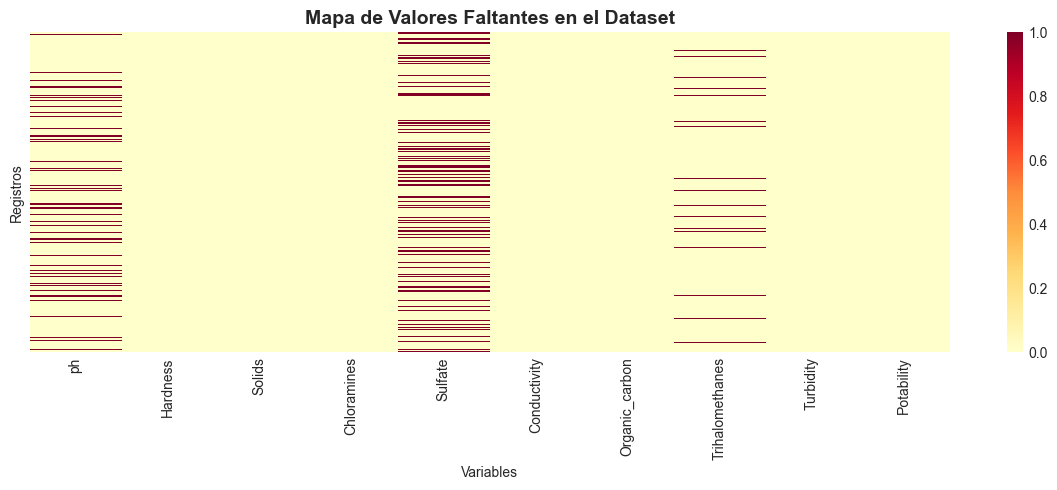

In [4]:
# Visualización de valores faltantes
plt.figure(figsize=(12, 5))

# Mapa de calor de datos faltantes
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd')
plt.title('Mapa de Valores Faltantes en el Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Variables')
plt.ylabel('Registros')
plt.tight_layout()
plt.show()

---
# 2. Técnicas de Limpieza de Datos (Data Cleaning)

## 2.1 Manejo de Valores Faltantes (Missing Values)

Los valores faltantes (`NaN`, `None`) son uno de los problemas más comunes. Tenemos dos estrategias principales:

1. **Eliminación**: Remover filas o columnas con datos faltantes
2. **Imputación**: Reemplazar los valores faltantes con estimaciones (media, mediana, moda, constante)

In [5]:
# Identificación de valores nulos
print("🔍 IDENTIFICACIÓN DE VALORES NULOS")
print("=" * 50)

# Métodos de detección
print("\n1. Verificar si hay algún nulo en todo el DataFrame:")
print(f"   df.isnull().values.any() → {df.isnull().values.any()}")

print("\n2. Total de nulos en todo el DataFrame:")
print(f"   df.isnull().sum().sum() → {df.isnull().sum().sum()}")

print("\n3. Nulos por columna:")
print(df.isnull().sum())

print(f"\n4. Filas con al menos un nulo: {df.isnull().any(axis=1).sum()}")
print(f"   Filas completas (sin nulos): {df.dropna().shape[0]}")

🔍 IDENTIFICACIÓN DE VALORES NULOS

1. Verificar si hay algún nulo en todo el DataFrame:
   df.isnull().values.any() → True

2. Total de nulos en todo el DataFrame:
   df.isnull().sum().sum() → 1434

3. Nulos por columna:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

4. Filas con al menos un nulo: 1265
   Filas completas (sin nulos): 2011


In [6]:
# ── ESTRATEGIA 1: Eliminación ──
print("❌ ESTRATEGIA 1: ELIMINACIÓN")
print("=" * 50)

# Eliminación por filas (se pierden registros)
df_sin_nulos_filas = df.dropna()
print(f"\nEliminación por filas:")
print(f"  Original: {df.shape[0]} filas")
print(f"  Después:  {df_sin_nulos_filas.shape[0]} filas")
print(f"  Perdidas: {df.shape[0] - df_sin_nulos_filas.shape[0]} filas ({(1 - df_sin_nulos_filas.shape[0]/df.shape[0])*100:.1f}%)")

# Eliminación por columnas (se pierden variables)
# Solo eliminar columnas con más del 30% de nulos
umbral = 0.30
cols_a_eliminar = [col for col in df.columns if df[col].isnull().sum()/len(df) > umbral]
print(f"\nColumnas con más de {umbral*100}% nulos: {cols_a_eliminar if cols_a_eliminar else 'Ninguna'}")

❌ ESTRATEGIA 1: ELIMINACIÓN

Eliminación por filas:
  Original: 3276 filas
  Después:  2011 filas
  Perdidas: 1265 filas (38.6%)

Columnas con más de 30.0% nulos: Ninguna


In [7]:
# ── ESTRATEGIA 2: Imputación ──
print("✅ ESTRATEGIA 2: IMPUTACIÓN")
print("=" * 50)

df_imputado = df.copy()

# Columnas con valores nulos
cols_con_nulos = df.columns[df.isnull().any()].tolist()
print(f"Columnas a imputar: {cols_con_nulos}")

for col in cols_con_nulos:
    media = df[col].mean()
    mediana = df[col].median()
    
    # Verificar la asimetría para elegir la mejor estrategia
    asimetria = df[col].skew()
    
    if abs(asimetria) > 1:  # Distribución muy asimétrica → usar mediana
        df_imputado[col].fillna(mediana, inplace=True)
        metodo = 'MEDIANA'
    else:  # Distribución relativamente simétrica → usar media
        df_imputado[col].fillna(media, inplace=True)
        metodo = 'MEDIA'
    
    print(f"  {col:20s} → Asimetría: {asimetria:+.2f} → Imputado con {metodo} ({media:.2f} / {mediana:.2f})")

print(f"\n✅ Nulos restantes: {df_imputado.isnull().sum().sum()}")

✅ ESTRATEGIA 2: IMPUTACIÓN
Columnas a imputar: ['ph', 'Sulfate', 'Trihalomethanes']
  ph                   → Asimetría: +0.03 → Imputado con MEDIA (7.08 / 7.04)
  Sulfate              → Asimetría: -0.04 → Imputado con MEDIA (333.78 / 333.07)
  Trihalomethanes      → Asimetría: -0.08 → Imputado con MEDIA (66.40 / 66.62)

✅ Nulos restantes: 0


C:\Users\DELL\AppData\Local\Temp\ipykernel_21596\4108477090.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputado[col].fillna(media, inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_21596\4108477090.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

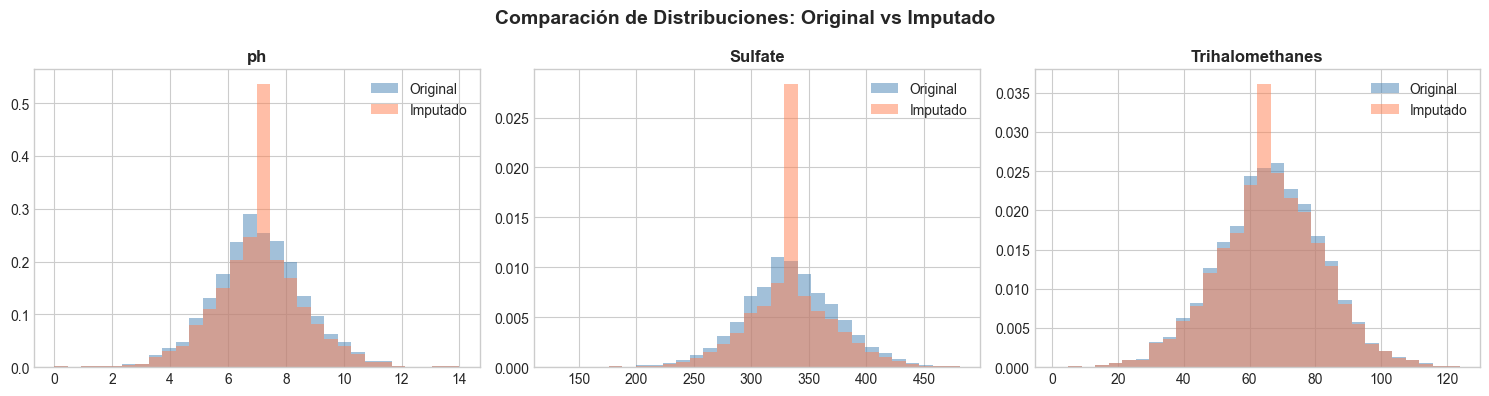

In [8]:
# Comparación visual: antes y después de la imputación
fig, axes = plt.subplots(1, len(cols_con_nulos), figsize=(5*len(cols_con_nulos), 4))
if len(cols_con_nulos) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_con_nulos):
    ax.hist(df[col].dropna(), bins=30, alpha=0.5, color='steelblue', label='Original', density=True)
    ax.hist(df_imputado[col], bins=30, alpha=0.5, color='coral', label='Imputado', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend()

plt.suptitle('Comparación de Distribuciones: Original vs Imputado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.2 Tratamiento de Datos Duplicados

Los registros duplicados pueden sesgar análisis estadísticos y el entrenamiento de modelos. Es importante detectarlos y decidir cómo manejarlos.

In [9]:
# Detección de duplicados
print("🔍 DETECCIÓN DE DUPLICADOS")
print("=" * 50)

# Duplicados exactos (todas las columnas iguales)
duplicados_exactos = df_imputado.duplicated().sum()
print(f"Duplicados exactos: {duplicados_exactos}")

# Duplicados basados en subconjunto de columnas
duplicados_parciales = df_imputado.duplicated(subset=['ph', 'Hardness', 'Solids']).sum()
print(f"Duplicados por [ph, Hardness, Solids]: {duplicados_parciales}")

# Mostrar filas duplicadas si existen
if duplicados_exactos > 0:
    print("\nEjemplo de filas duplicadas:")
    display(df_imputado[df_imputado.duplicated(keep=False)].head(10))

🔍 DETECCIÓN DE DUPLICADOS
Duplicados exactos: 0
Duplicados por [ph, Hardness, Solids]: 0


In [10]:
# Eliminación de duplicados
filas_antes = df_imputado.shape[0]
df_imputado = df_imputado.drop_duplicates()
filas_despues = df_imputado.shape[0]

print(f"Filas antes: {filas_antes}")
print(f"Filas después: {filas_despues}")
print(f"Eliminadas: {filas_antes - filas_despues}")

Filas antes: 3276
Filas después: 3276
Eliminadas: 0


## 2.3 Detección y Manejo de Outliers (Valores Atípicos)

Los **outliers** son valores que se desvían significativamente del resto de los datos. Pueden ser:
- **Legítimos**: valores reales pero extremos
- **Errores**: errores de medición o captura

### Métodos de detección:
1. **IQR (Rango Intercuartílico)**: Valores fuera de [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
2. **Z-score (Puntuación Z)**: Valores con |Z| > 3 (más de 3 desviaciones estándar)

In [11]:
# ── MÉTODO 1: Detección por IQR ──
print("📐 DETECCIÓN DE OUTLIERS — MÉTODO IQR")
print("=" * 55)

def detectar_outliers_iqr(dataframe, columna):
    """Detecta outliers usando el método IQR."""
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

cols_numericas = df_imputado.select_dtypes(include=[np.number]).columns.tolist()
cols_numericas = [c for c in cols_numericas if c != 'Potability']

print(f"{'Columna':20s} {'Outliers':>10s} {'% del total':>12s} {'Lím. Inf':>12s} {'Lím. Sup':>12s}")
print("-" * 70)

for col in cols_numericas:
    outliers, li, ls = detectar_outliers_iqr(df_imputado, col)
    pct = len(outliers) / len(df_imputado) * 100
    print(f"{col:20s} {len(outliers):10d} {pct:11.2f}% {li:12.2f} {ls:12.2f}")

📐 DETECCIÓN DE OUTLIERS — MÉTODO IQR
Columna                Outliers  % del total     Lím. Inf     Lím. Sup
----------------------------------------------------------------------
ph                          142        4.33%         3.89        10.26
Hardness                     83        2.53%       117.13       276.39
Solids                       47        1.43%     -1832.42     44831.87
Chloramines                  61        1.86%         3.15        11.10
Sulfate                     264        8.06%       267.16       400.32
Conductivity                 11        0.34%       191.65       655.88
Organic_carbon               25        0.76%         5.33        23.30
Trihalomethanes              54        1.65%        26.62       106.70
Turbidity                    19        0.58%         1.85         6.09


In [13]:
# ── MÉTODO 2: Detección por Z-score ──
print("📐 DETECCIÓN DE OUTLIERS — MÉTODO Z-SCORE")
print("=" * 55)

from scipy.stats import zscore

# Calcular Z-scores para todas las columnas numéricas
z_scores = np.abs(zscore(df_imputado[cols_numericas], nan_policy='omit'))

# Outliers: valores con Z-score > 3
umbral_z = 3
print(f"Umbral Z-score: |Z| > {umbral_z}\n")

print(f"{'Columna':20s} {'Outliers (Z>3)':>15s} {'% del total':>12s}")
print("-" * 50)

for i, col in enumerate(cols_numericas):
    n_outliers = (z_scores.iloc[:, i] > umbral_z).sum()
    pct = n_outliers / len(df_imputado) * 100
    print(f"{col:20s} {n_outliers:15d} {pct:11.2f}%")

📐 DETECCIÓN DE OUTLIERS — MÉTODO Z-SCORE
Umbral Z-score: |Z| > 3

Columna               Outliers (Z>3)  % del total
--------------------------------------------------
ph                                28        0.85%
Hardness                          18        0.55%
Solids                            20        0.61%
Chloramines                       20        0.61%
Sulfate                           34        1.04%
Conductivity                       7        0.21%
Organic_carbon                     4        0.12%
Trihalomethanes                   18        0.55%
Turbidity                          9        0.27%


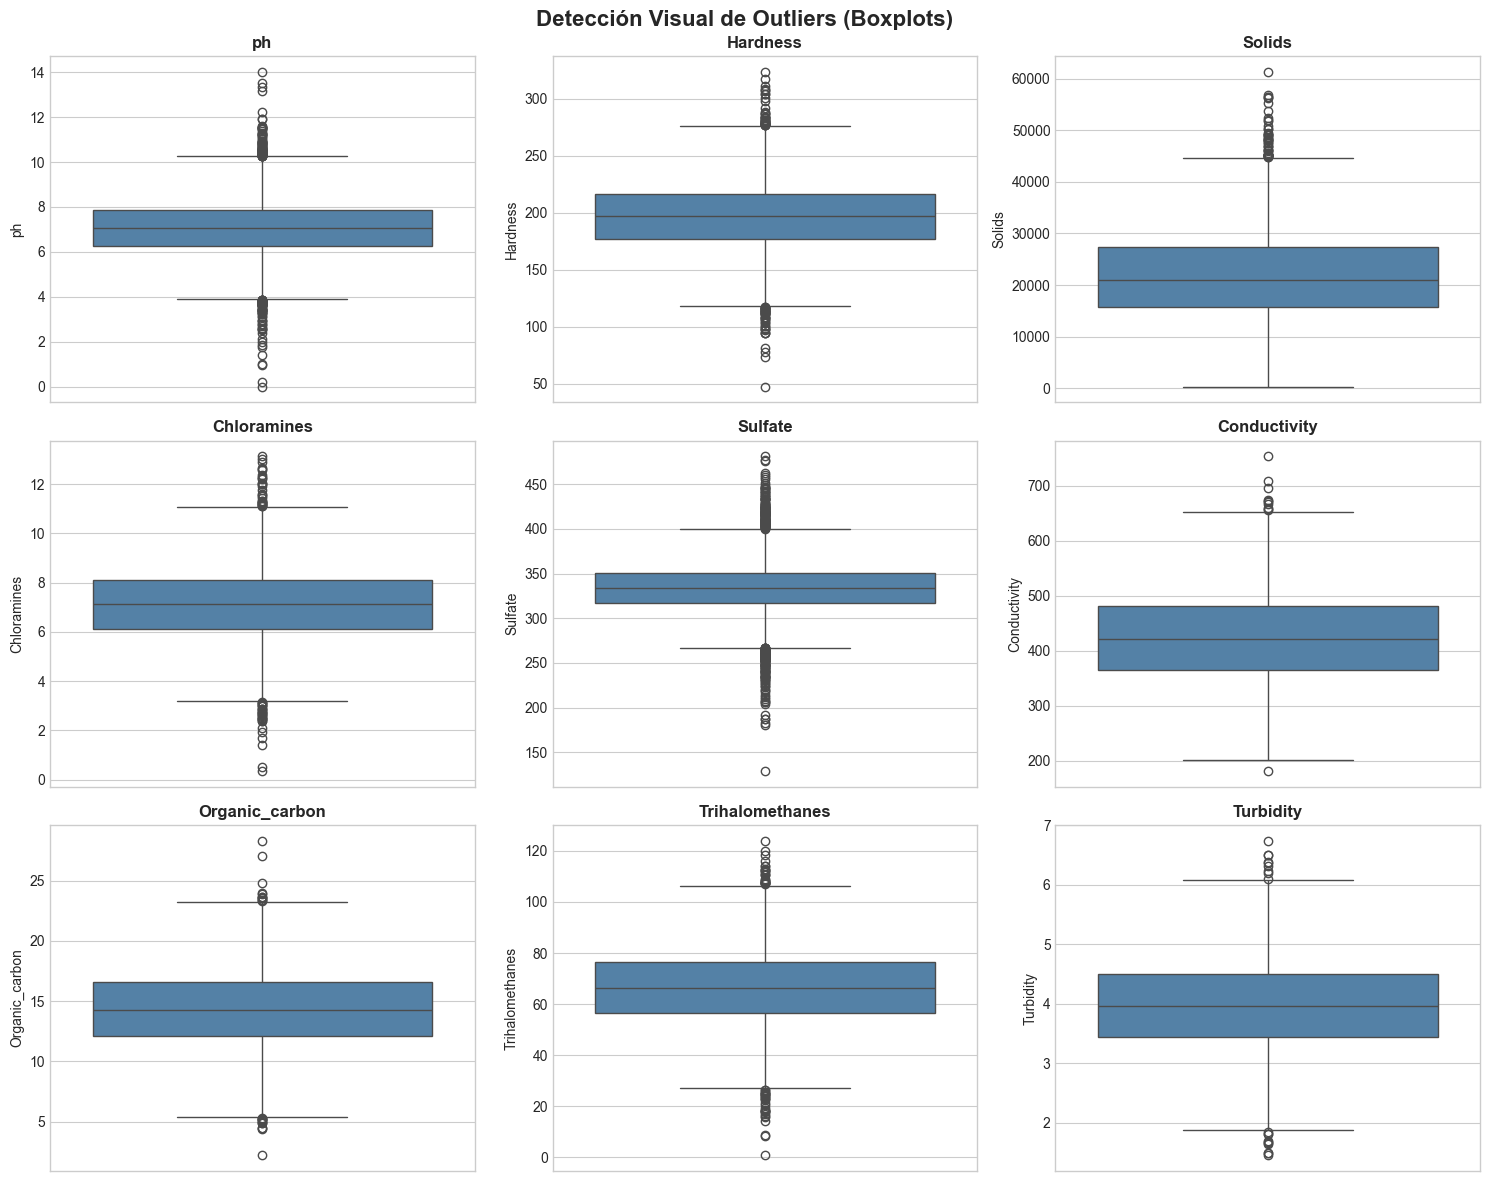

In [14]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Detección Visual de Outliers (Boxplots)', fontsize=16, fontweight='bold')

for i, col in enumerate(cols_numericas):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df_imputado, y=col, ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Manejo de outliers: Imputación con límites IQR (winsorización)
print("🔧 MANEJO DE OUTLIERS — WINSORIZACIÓN")
print("=" * 50)

df_limpio = df_imputado.copy()

for col in cols_numericas:
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR
    
    # Reemplazar outliers por los límites
    antes = ((df_limpio[col] < li) | (df_limpio[col] > ls)).sum()
    df_limpio[col] = df_limpio[col].clip(lower=li, upper=ls)
    despues = ((df_limpio[col] < li) | (df_limpio[col] > ls)).sum()
    
    if antes > 0:
        print(f"  {col}: {antes} outliers winsorizados")

print(f"\n✅ Dataset limpio: {df_limpio.shape}")

🔧 MANEJO DE OUTLIERS — WINSORIZACIÓN
  ph: 142 outliers winsorizados
  Hardness: 83 outliers winsorizados
  Solids: 47 outliers winsorizados
  Chloramines: 61 outliers winsorizados
  Sulfate: 264 outliers winsorizados
  Conductivity: 11 outliers winsorizados
  Organic_carbon: 25 outliers winsorizados
  Trihalomethanes: 54 outliers winsorizados
  Turbidity: 19 outliers winsorizados

✅ Dataset limpio: (3276, 10)


---
# 3. Transformación y Preprocesamiento de Datos

## 3.1 Normalización y Estandarización de Datos Numéricos

Muchos algoritmos de ML requieren que las variables estén en la misma escala:

- **Normalización (Min-Max)**: Escala los datos al rango [0, 1]
  $$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

- **Estandarización (Z-score)**: Transforma para tener media = 0 y desviación estándar = 1
  $$X_{std} = \frac{X - \mu}{\sigma}$$

In [16]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# ── Normalización Min-Max ──
print("📊 NORMALIZACIÓN MIN-MAX [0, 1]")
print("=" * 50)

scaler_minmax = MinMaxScaler()
df_normalizado = pd.DataFrame(
    scaler_minmax.fit_transform(df_limpio[cols_numericas]),
    columns=cols_numericas
)
print("Estadísticas después de normalización:")
display(df_normalizado.describe().round(3))

📊 NORMALIZACIÓN MIN-MAX [0, 1]
Estadísticas después de normalización:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,3276.000,3276.000,3276.000,3276.000,3276.000,3276.000,3276.000,3276.000,3276.000
mean,0.501,0.498,0.486,0.500,0.500,0.505,0.498,0.497,0.499
std,0.217,0.201,0.193,0.194,0.239,0.174,0.183,0.193,0.183
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.375,0.375,0.345,0.375,0.375,0.375,0.375,0.375,0.375
50%,0.501,0.501,0.463,0.501,0.500,0.496,0.495,0.497,0.496
75%,0.625,0.625,0.607,0.625,0.625,0.625,0.625,0.625,0.625
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [17]:
# ── Estandarización Z-score ──
print("📊 ESTANDARIZACIÓN Z-SCORE (media=0, std=1)")
print("=" * 50)

scaler_std = StandardScaler()
df_estandarizado = pd.DataFrame(
    scaler_std.fit_transform(df_limpio[cols_numericas]),
    columns=cols_numericas
)
print("Estadísticas después de estandarización:")
display(df_estandarizado.describe().round(3))

📊 ESTANDARIZACIÓN Z-SCORE (media=0, std=1)
Estadísticas después de estandarización:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,3276.000,3276.000,3276.000,3276.000,3276.000,3276.000,3276.000,3276.000,3276.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.309,-2.476,-2.518,-2.575,-2.098,-2.911,-2.724,-2.570,-2.728
25%,-0.581,-0.610,-0.732,-0.644,-0.526,-0.750,-0.674,-0.631,-0.679
50%,0.001,0.018,-0.120,0.006,-0.000,-0.053,-0.020,-0.002,-0.015
75%,0.572,0.633,0.626,0.643,0.523,0.691,0.692,0.662,0.688
max,2.300,2.499,2.662,2.574,2.095,2.852,2.741,2.601,2.737


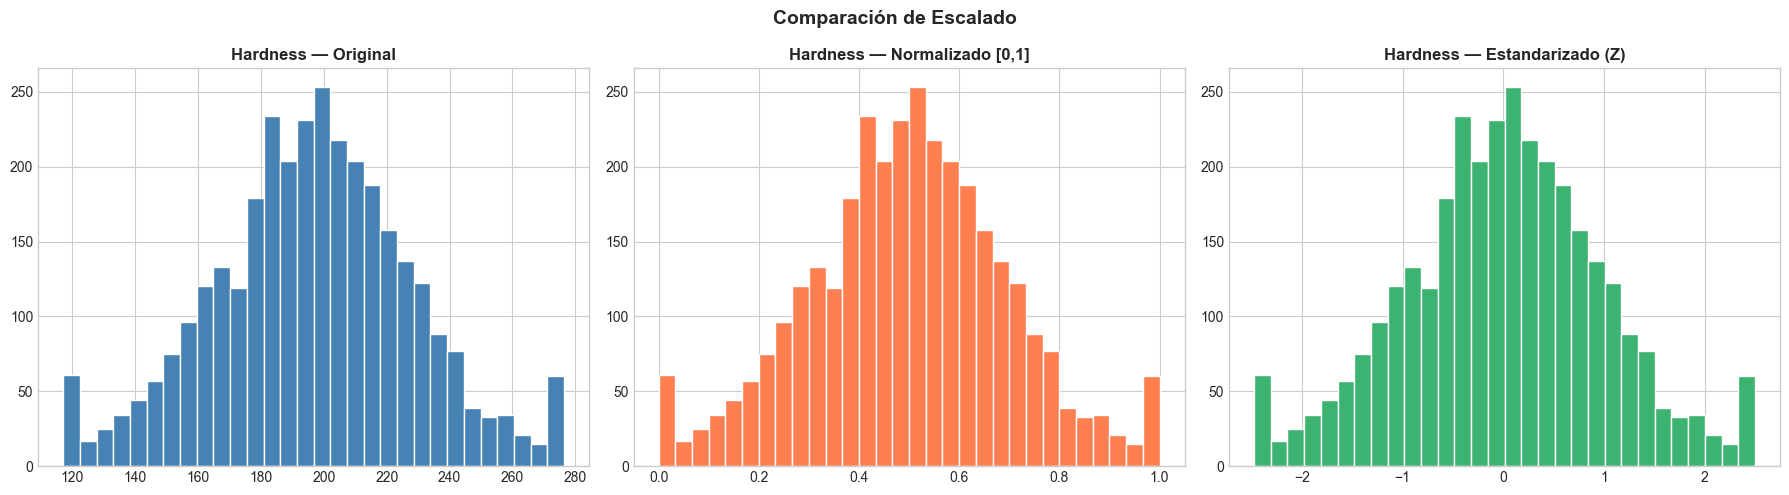

In [18]:
# Comparación visual: Original vs Normalizado vs Estandarizado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

col_ejemplo = 'Hardness'

axes[0].hist(df_limpio[col_ejemplo], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'{col_ejemplo} — Original', fontweight='bold')

axes[1].hist(df_normalizado[col_ejemplo], bins=30, color='coral', edgecolor='white')
axes[1].set_title(f'{col_ejemplo} — Normalizado [0,1]', fontweight='bold')

axes[2].hist(df_estandarizado[col_ejemplo], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title(f'{col_ejemplo} — Estandarizado (Z)', fontweight='bold')

plt.suptitle('Comparación de Escalado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.2 Codificación de Variables Categóricas

Los modelos de ML trabajan con números, por lo que las variables categóricas deben ser codificadas:

- **Label Encoding**: Asigna un número entero a cada categoría. Ideal para variables **ordinales** (con orden).
- **One-Hot Encoding**: Crea una columna binaria por cada categoría. Ideal para variables **nominales** (sin orden).

In [19]:
# Crear una variable categórica de ejemplo basada en pH
# para demostrar los métodos de codificación

df_encoding = df_limpio.copy()

# Variable ordinal: Nivel de pH (bajo, medio, alto)
df_encoding['pH_nivel'] = pd.cut(
    df_encoding['ph'],
    bins=[0, 6.5, 7.5, 14],
    labels=['Ácido', 'Neutro', 'Alcalino']
)

# Variable nominal: Clasificación de calidad
df_encoding['calidad_agua'] = pd.cut(
    df_encoding['Turbidity'],
    bins=[0, 3, 4, float('inf')],
    labels=['Buena', 'Aceptable', 'Mala']
)

print("Variables categóricas creadas:")
print(f"\npH_nivel:\n{df_encoding['pH_nivel'].value_counts()}")
print(f"\ncalidad_agua:\n{df_encoding['calidad_agua'].value_counts()}")

Variables categóricas creadas:

pH_nivel:
pH_nivel
Neutro      1249
Alcalino    1059
Ácido        968
Name: count, dtype: int64

calidad_agua:
calidad_agua
Mala         1570
Aceptable    1341
Buena         365
Name: count, dtype: int64


In [20]:
# ── Label Encoding (para variable ordinal) ──
from sklearn.preprocessing import LabelEncoder

print("🏷️ LABEL ENCODING (Variable Ordinal: pH_nivel)")
print("=" * 50)

le = LabelEncoder()
df_encoding['pH_nivel_encoded'] = le.fit_transform(df_encoding['pH_nivel'])

# Mapeo de etiquetas
mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapeo: {mapeo}")
print(df_encoding[['pH_nivel', 'pH_nivel_encoded']].drop_duplicates())

🏷️ LABEL ENCODING (Variable Ordinal: pH_nivel)
Mapeo: {'Alcalino': np.int64(0), 'Neutro': np.int64(1), 'Ácido': np.int64(2)}
   pH_nivel  pH_nivel_encoded
0    Neutro                 1
1     Ácido                 2
2  Alcalino                 0


In [21]:
# ── One-Hot Encoding (para variable nominal) ──
print("🔥 ONE-HOT ENCODING (Variable Nominal: calidad_agua)")
print("=" * 55)

# Método con pandas (get_dummies)
df_onehot = pd.get_dummies(df_encoding[['calidad_agua']], prefix='calidad', dtype=int)
print("\nResultado del One-Hot Encoding:")
display(df_onehot.head(10))

print(f"\nColumnas creadas: {df_onehot.columns.tolist()}")

🔥 ONE-HOT ENCODING (Variable Nominal: calidad_agua)

Resultado del One-Hot Encoding:


,calidad_Buena,calidad_Aceptable,calidad_Mala
0,1,0,0
1,0,0,1
2,0,1,0
3,0,0,1
4,0,0,1
5,1,0,0
6,1,0,0
7,0,0,1
8,0,1,0
9,0,0,1



Columnas creadas: ['calidad_Buena', 'calidad_Aceptable', 'calidad_Mala']


## 3.3 Discretización (Binning)

La **discretización** convierte variables numéricas continuas en categorías discretas ("bins" o intervalos). Útil cuando:
- Se necesita simplificar el análisis
- Se quieren crear grupos significativos
- Algunos algoritmos funcionan mejor con datos categóricos

In [22]:
# Discretización de la variable Hardness (Dureza del agua)
print("📦 DISCRETIZACIÓN — Dureza del Agua")
print("=" * 50)

# Método 1: Bins de igual ancho (cut)
df_bins = df_limpio.copy()
df_bins['Hardness_bin_equal'] = pd.cut(df_bins['Hardness'], bins=4,
                                        labels=['Blanda', 'Moderada', 'Dura', 'Muy Dura'])

# Método 2: Bins de igual frecuencia (qcut)
df_bins['Hardness_bin_quantile'] = pd.qcut(df_bins['Hardness'], q=4,
                                            labels=['Q1', 'Q2', 'Q3', 'Q4'])

print("\nBins de igual ancho:")
print(df_bins['Hardness_bin_equal'].value_counts().sort_index())

print("\nBins de igual frecuencia (cuartiles):")
print(df_bins['Hardness_bin_quantile'].value_counts().sort_index())

📦 DISCRETIZACIÓN — Dureza del Agua

Bins de igual ancho:
Hardness_bin_equal
Blanda       364
Moderada    1265
Dura        1325
Muy Dura     322
Name: count, dtype: int64

Bins de igual frecuencia (cuartiles):
Hardness_bin_quantile
Q1    819
Q2    819
Q3    819
Q4    819
Name: count, dtype: int64


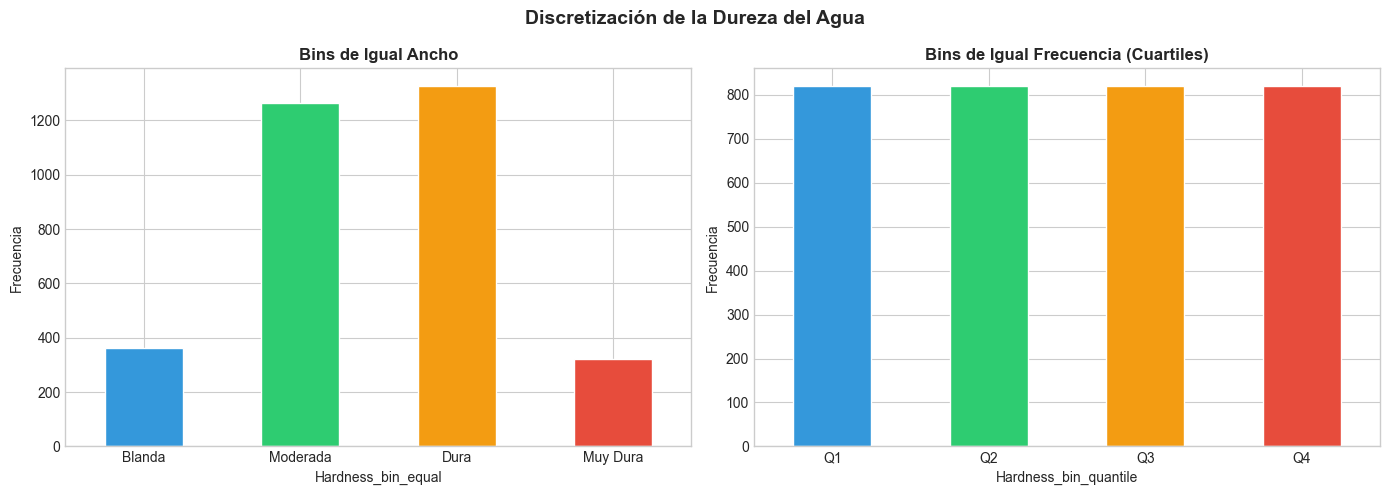

In [23]:
# Visualización de la discretización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_bins['Hardness_bin_equal'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[0].set_title('Bins de Igual Ancho', fontweight='bold')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

df_bins['Hardness_bin_quantile'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[1].set_title('Bins de Igual Frecuencia (Cuartiles)', fontweight='bold')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Discretización de la Dureza del Agua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 4. Ingeniería de Características (Feature Engineering)

## 4.1 Creación de Nuevas Variables

La ingeniería de características consiste en crear **nuevas variables informativas** a partir de las existentes para mejorar el rendimiento de los modelos.

In [24]:
# Creación de nuevas características relevantes para calidad del agua
print("🔧 INGENIERÍA DE CARACTERÍSTICAS")
print("=" * 50)

df_features = df_limpio.copy()

# 1. Ratio entre sólidos y conductividad
df_features['ratio_solidos_conductividad'] = df_features['Solids'] / df_features['Conductivity']

# 2. Indicador de pH neutro (entre 6.5 y 8.5 según OMS)
df_features['ph_neutral'] = ((df_features['ph'] >= 6.5) & (df_features['ph'] <= 8.5)).astype(int)

# 3. Índice de contaminación orgánica (carbono + trihalometanos)
df_features['indice_contaminacion'] = (
    df_features['Organic_carbon'] * 0.5 + df_features['Trihalomethanes'] * 0.5
)

# 4. Logaritmo de Solids (para reducir asimetría)
df_features['log_solids'] = np.log1p(df_features['Solids'])

# 5. Interacción entre Hardness y Sulfate
df_features['hardness_x_sulfate'] = df_features['Hardness'] * df_features['Sulfate']

print("Nuevas variables creadas:")
nuevas_cols = ['ratio_solidos_conductividad', 'ph_neutral', 'indice_contaminacion',
               'log_solids', 'hardness_x_sulfate']
display(df_features[nuevas_cols].describe().round(2))

🔧 INGENIERÍA DE CARACTERÍSTICAS
Nuevas variables creadas:


,ratio_solidos_conductividad,ph_neutral,indice_contaminacion,log_solids,hardness_x_sulfate
count,3276.00,3276.00,3276.00,3276.00,3276.00
mean,53.39,0.56,40.35,9.91,65475.42
std,23.66,0.50,7.90,0.44,12006.91
min,0.89,0.00,16.68,5.77,31290.92
25%,36.33,0.00,35.45,9.66,58372.69
50%,50.27,1.00,40.31,9.95,65080.53
75%,66.09,1.00,45.58,10.22,72543.81
max,174.47,1.00,63.28,10.71,110646.25


## 4.2 Extracción de Características

Consiste en derivar información útil de datos complejos. Aunque nuestro dataset no tiene fechas ni texto, demostraremos ambas técnicas con ejemplos simulados.

In [25]:
# Simulación de extracción de características de fechas
print("📅 EXTRACCIÓN DE CARACTERÍSTICAS — FECHAS")
print("=" * 50)

# Simular fechas de muestreo
np.random.seed(42)
fechas = pd.date_range(start='2023-01-01', periods=len(df_features), freq='2h')
df_features['fecha_muestreo'] = fechas[:len(df_features)]

# Extraer componentes de la fecha
df_features['anio'] = df_features['fecha_muestreo'].dt.year
df_features['mes'] = df_features['fecha_muestreo'].dt.month
df_features['dia'] = df_features['fecha_muestreo'].dt.day
df_features['dia_semana'] = df_features['fecha_muestreo'].dt.dayofweek  # 0=Lunes
df_features['hora'] = df_features['fecha_muestreo'].dt.hour
df_features['trimestre'] = df_features['fecha_muestreo'].dt.quarter

print("Características extraídas de la fecha:")
display(df_features[['fecha_muestreo', 'anio', 'mes', 'dia', 'dia_semana', 'hora', 'trimestre']].head())

📅 EXTRACCIÓN DE CARACTERÍSTICAS — FECHAS
Características extraídas de la fecha:


,fecha_muestreo,anio,mes,dia,dia_semana,hora,trimestre
0,2023-01-01 00:00:00,2023,1,1,6,0,1
1,2023-01-01 02:00:00,2023,1,1,6,2,1
2,2023-01-01 04:00:00,2023,1,1,6,4,1
3,2023-01-01 06:00:00,2023,1,1,6,6,1
4,2023-01-01 08:00:00,2023,1,1,6,8,1


---
# 5. Aplicación Práctica con Librerías de Python

## 5.1 Manipulación Avanzada con Pandas

### `apply()`, `map()` y `transform()`

In [26]:
# ── apply() — Aplicar una función a filas o columnas ──
print("🔧 FUNCIÓN apply()")
print("=" * 50)

df_pandas = df_limpio.copy()

# apply() sobre una columna (Series)
def clasificar_ph(ph):
    """Clasifica el pH del agua."""
    if ph < 6.5:
        return 'Ácido'
    elif ph <= 8.5:
        return 'Neutro'
    else:
        return 'Alcalino'

df_pandas['ph_clase'] = df_pandas['ph'].apply(clasificar_ph)
print("Clasificación del pH con apply():")
print(df_pandas['ph_clase'].value_counts())

# apply() sobre filas (axis=1) — crear un score de riesgo
def score_riesgo(fila):
    """Calcula un score de riesgo hídrico basado en múltiples variables."""
    score = 0
    if fila['ph'] < 6.5 or fila['ph'] > 8.5:
        score += 1
    if fila['Turbidity'] > 4:
        score += 1
    if fila['Chloramines'] > 8:
        score += 1
    return score

df_pandas['riesgo'] = df_pandas.apply(score_riesgo, axis=1)
print(f"\nDistribución del score de riesgo:")
print(df_pandas['riesgo'].value_counts().sort_index())

🔧 FUNCIÓN apply()
Clasificación del pH con apply():
ph_clase
Neutro      1819
Ácido        968
Alcalino     489
Name: count, dtype: int64

Distribución del score de riesgo:
riesgo
0     688
1    1449
2     935
3     204
Name: count, dtype: int64


In [27]:
# ── map() — Mapear valores a otros valores ──
print("🗺️ FUNCIÓN map()")
print("=" * 50)

# map() con diccionario
df_pandas['potabilidad_texto'] = df_pandas['Potability'].map({
    0: 'No Potable',
    1: 'Potable'
})
print("Mapeo de Potabilidad:")
print(df_pandas[['Potability', 'potabilidad_texto']].drop_duplicates())

🗺️ FUNCIÓN map()
Mapeo de Potabilidad:
     Potability potabilidad_texto
0             0        No Potable
250           1           Potable


In [28]:
# ── transform() — Transformaciones que mantienen el índice ──
print("🔄 FUNCIÓN transform()")
print("=" * 50)

# transform() es ideal para operaciones con groupby que devuelven
# un valor por cada fila original

# Media del pH por grupo de potabilidad (broadcast al tamaño original)
df_pandas['ph_media_grupo'] = df_pandas.groupby('Potability')['ph'].transform('mean')

# Diferencia respecto a la media del grupo
df_pandas['ph_diff_grupo'] = df_pandas['ph'] - df_pandas['ph_media_grupo']

print("pH original vs media del grupo vs diferencia:")
display(df_pandas[['ph', 'Potability', 'ph_media_grupo', 'ph_diff_grupo']].head(10))

🔄 FUNCIÓN transform()
pH original vs media del grupo vs diferencia:


,ph,Potability,ph_media_grupo,ph_diff_grupo
0,7.080795,0,7.082129,-0.001335
1,3.889107,0,7.082129,-3.193022
2,8.099124,0,7.082129,1.016995
3,8.316766,0,7.082129,1.234637
4,9.092223,0,7.082129,2.010094
5,5.584087,0,7.082129,-1.498042
6,10.223862,0,7.082129,3.141733
7,8.635849,0,7.082129,1.553720
8,7.080795,0,7.082129,-0.001335
9,10.258615,0,7.082129,3.176486


### `groupby()` — Agregación y Resumen de Datos

In [29]:
# Agregación con groupby()
print("📊 AGREGACIÓN CON groupby()")
print("=" * 50)

# Estadísticas por grupo de potabilidad
resumen = df_pandas.groupby('Potability')[cols_numericas].agg(['mean', 'std', 'min', 'max'])
print("Resumen estadístico por Potabilidad:")
display(resumen.round(2))

📊 AGREGACIÓN CON groupby()
Resumen estadístico por Potabilidad:


ph                    Hardness                           Solids  \
            mean   std   min    max     mean    std     min     max      mean   
Potability                                                                      
0           7.08  1.44  3.89  10.26   196.73  30.70  117.13  276.39  21738.28   
1           7.08  1.28  3.89  10.26   195.86  33.98  117.13  276.39  22299.22   

                                      Chloramines                   Sulfate  \
                std     min       max        mean   std   min   max    mean   
Potability                                                                    
0           8416.55  320.94  44831.87        7.09  1.48  3.15  11.1  334.19   
1           8853.87  728.75  44831.87        7.17  1.64  3.15  11.1  333.17   

                                  Conductivity                         \
              std     min     max         mean    std     min     max   
Potability                                                              
0           29.29  267.16  400.32       426.64  79.71  191.65  655.88   
1           35.30  267.16  400.32       425.34  81.91  201.62  655.88   

           Organic_carbon                   Trihalomethanes                \
                     mean   std   min   max            mean    std    min   
Potability                                                                  
0                   14.36  3.31  5.33  23.3           66.34  15.40  26.62   
1                   14.16  3.25  5.33  23.3           66.55  15.62  26.62   

                  Turbidity                    
              max      mean   std   min   max  
Potability                                     
0           106.7      3.97  0.78  1.85  6.09  
1           106.7      3.97  0.78  1.85  6.09

In [30]:
# Múltiples funciones de agregación personalizadas
resumen_custom = df_pandas.groupby('Potability').agg(
    ph_promedio=('ph', 'mean'),
    ph_mediana=('ph', 'median'),
    dureza_max=('Hardness', 'max'),
    turbidez_promedio=('Turbidity', 'mean'),
    n_muestras=('ph', 'count')
).round(2)

resumen_custom.index = ['No Potable', 'Potable']
print("Resumen personalizado:")
display(resumen_custom)

Resumen personalizado:


,ph_promedio,ph_mediana,dureza_max,turbidez_promedio,n_muestras
No Potable,7.08,7.08,276.39,3.97,1998
Potable,7.08,7.08,276.39,3.97,1278


### Combinación de DataFrames: `merge`, `join`, `concat`

In [31]:
# ── concat() — Concatenar DataFrames ──
print("🔗 CONCATENACIÓN CON concat()")
print("=" * 50)

# Dividir en dos partes y recombinar (simulación)
df_parte1 = df_limpio.iloc[:100]  # Primeras 100 filas
df_parte2 = df_limpio.iloc[100:200]  # Filas 100-200

# Concatenar verticalmente (apilar filas)
df_concat = pd.concat([df_parte1, df_parte2], axis=0, ignore_index=True)
print(f"Parte 1: {df_parte1.shape} + Parte 2: {df_parte2.shape} = Concatenado: {df_concat.shape}")

# Concatenar horizontalmente (agregar columnas)
df_info1 = df_limpio[['ph', 'Hardness']].head(5)
df_info2 = df_limpio[['Turbidity', 'Potability']].head(5)
df_concat_h = pd.concat([df_info1, df_info2], axis=1)
print(f"\nConcatenación horizontal:")
display(df_concat_h)

🔗 CONCATENACIÓN CON concat()
Parte 1: (100, 10) + Parte 2: (100, 10) = Concatenado: (200, 10)

Concatenación horizontal:


,ph,Hardness,Turbidity,Potability
0,7.080795,204.890455,2.963135,0
1,3.889107,129.422921,4.500656,0
2,8.099124,224.236259,3.055934,0
3,8.316766,214.373394,4.628771,0
4,9.092223,181.101509,4.075075,0


In [32]:
# ── merge() — Unión tipo SQL ──
print("🔗 MERGE (Unión tipo SQL)")
print("=" * 50)

# Crear tablas de ejemplo para demostrar merge
# Tabla de muestras
muestras = pd.DataFrame({
    'muestra_id': [1, 2, 3, 4, 5],
    'ph': [7.2, 6.8, 8.1, 5.5, 7.0],
    'estacion_id': ['E01', 'E02', 'E01', 'E03', 'E02']
})

# Tabla de estaciones de monitoreo
estaciones = pd.DataFrame({
    'estacion_id': ['E01', 'E02', 'E03'],
    'ubicacion': ['Río Bogotá', 'Laguna Fúquene', 'Embalse Tominé'],
    'departamento': ['Cundinamarca', 'Cundinamarca', 'Cundinamarca']
})

# Inner merge
df_merged = pd.merge(muestras, estaciones, on='estacion_id', how='inner')
print("Resultado del merge (inner join):")
display(df_merged)

# Tipos de merge:
print("\nTipos de merge disponibles:")
print("  - inner: solo filas con coincidencia en ambas tablas")
print("  - left:  todas las filas de la tabla izquierda")
print("  - right: todas las filas de la tabla derecha")
print("  - outer: todas las filas de ambas tablas")

🔗 MERGE (Unión tipo SQL)
Resultado del merge (inner join):


,muestra_id,ph,estacion_id,ubicacion,departamento
0,1,7.2,E01,Río Bogotá,Cundinamarca
1,2,6.8,E02,Laguna Fúquene,Cundinamarca
2,3,8.1,E01,Río Bogotá,Cundinamarca
3,4,5.5,E03,Embalse Tominé,Cundinamarca
4,5,7.0,E02,Laguna Fúquene,Cundinamarca



Tipos de merge disponibles:
  - inner: solo filas con coincidencia en ambas tablas
  - left:  todas las filas de la tabla izquierda
  - right: todas las filas de la tabla derecha
  - outer: todas las filas de ambas tablas


---
## Conclusiones

En esta semana aprendimos el pipeline completo de preparación de datos:

1. **Calidad de Datos**: Diagnosticamos problemas usando las 5 dimensiones (exactitud, completitud, consistencia, validez, unicidad)
2. **Limpieza**: Tratamos valores faltantes (imputación), duplicados y outliers (IQR, Z-score)
3. **Transformación**: Aplicamos normalización Min-Max, estandarización Z-score, Label/One-Hot Encoding y discretización
4. **Ingeniería de Características**: Creamos nuevas variables informativas y extrajimos componentes de fechas
5. **Pandas Avanzado**: Dominamos `apply()`, `map()`, `transform()`, `groupby()` y combinación de DataFrames

**Próxima semana:** Análisis de correlación, supuestos estadísticos (homoscedasticidad, multicolinealidad) y formulación de hipótesis.